In [34]:
#Q13 workflow
#gather packages
!pip install ISLP
import pandas as pd
import numpy as np
import statsmodels.api as sm

from ISLP import load_data
from ISLP.models import ModelSpec as MS, summarize
from ISLP import confusion_table

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

In [35]:
#Create dataframe. EDA
Weekly = load_data("Weekly")
Weekly.head()

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
0,1990,0.816,1.572,-3.936,-0.229,-3.484,0.154976,-0.270,Down
1,1990,-0.270,0.816,1.572,-3.936,-0.229,0.148574,-2.576,Down
2,1990,-2.576,-0.270,0.816,1.572,-3.936,0.159837,3.514,Up
3,1990,3.514,-2.576,-0.270,0.816,1.572,0.161630,0.712,Up
4,1990,0.712,3.514,-2.576,-0.270,0.816,0.153728,1.178,Up


In [36]:
#EDA
Weekly.describe()


,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today
count,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000
mean,2000.048669,0.150585,0.151079,0.147205,0.145818,0.139893,1.574618,0.149899
std,6.033182,2.357013,2.357254,2.360502,2.360279,2.361285,1.686636,2.356927
min,1990.000000,-18.195000,-18.195000,-18.195000,-18.195000,-18.195000,0.087465,-18.195000
25%,1995.000000,-1.154000,-1.154000,-1.158000,-1.158000,-1.166000,0.332022,-1.154000
50%,2000.000000,0.241000,0.241000,0.241000,0.238000,0.234000,1.002680,0.241000
75%,2005.000000,1.405000,1.409000,1.409000,1.409000,1.405000,2.053727,1.405000
max,2010.000000,12.026000,12.026000,12.026000,12.026000,12.026000,9.328214,12.026000


In [37]:
#EDA
Weekly.corr(numeric_only=True)

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today
Year,1.000000,-0.032289,-0.033390,-0.030006,-0.031128,-0.030519,0.841942,-0.032460
Lag1,-0.032289,1.000000,-0.074853,0.058636,-0.071274,-0.008183,-0.064951,-0.075032
Lag2,-0.033390,-0.074853,1.000000,-0.075721,0.058382,-0.072499,-0.085513,0.059167
Lag3,-0.030006,0.058636,-0.075721,1.000000,-0.075396,0.060657,-0.069288,-0.071244
Lag4,-0.031128,-0.071274,0.058382,-0.075396,1.000000,-0.075675,-0.061075,-0.007826
Lag5,-0.030519,-0.008183,-0.072499,0.060657,-0.075675,1.000000,-0.058517,0.011013
Volume,0.841942,-0.064951,-0.085513,-0.069288,-0.061075,-0.058517,1.000000,-0.033078
Today,-0.032460,-0.075032,0.059167,-0.071244,-0.007826,0.011013,-0.033078,1.000000


In [38]:
#EDA
Weekly["Direction"].value_counts()


,count
Direction,
Up,605
Down,484


<Axes: >

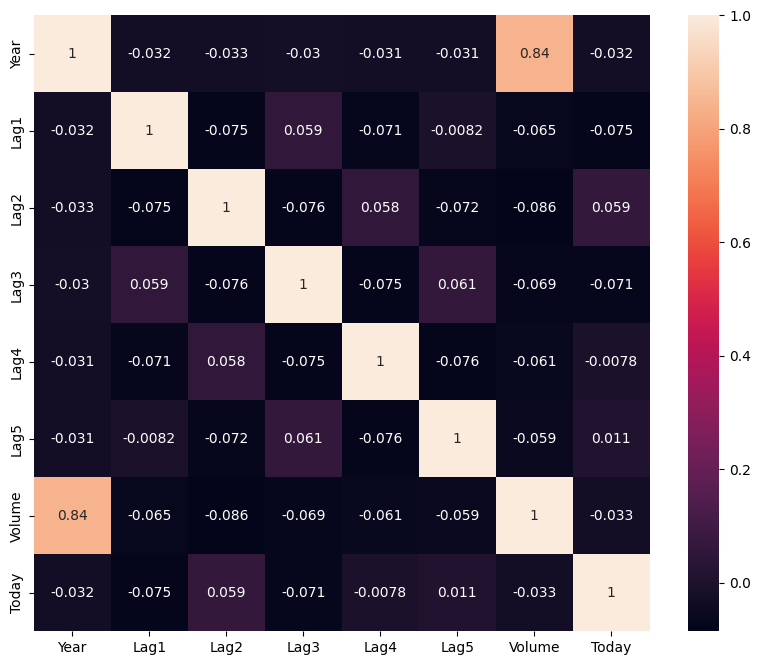

In [39]:
#EDA
numeric_cols = Weekly.select_dtypes(include=np.number).columns
Weekly_numeric = Weekly[numeric_cols]


plt.figure(figsize=(10, 8))
sns.heatmap(Weekly_numeric.corr(), annot=True, square=True)

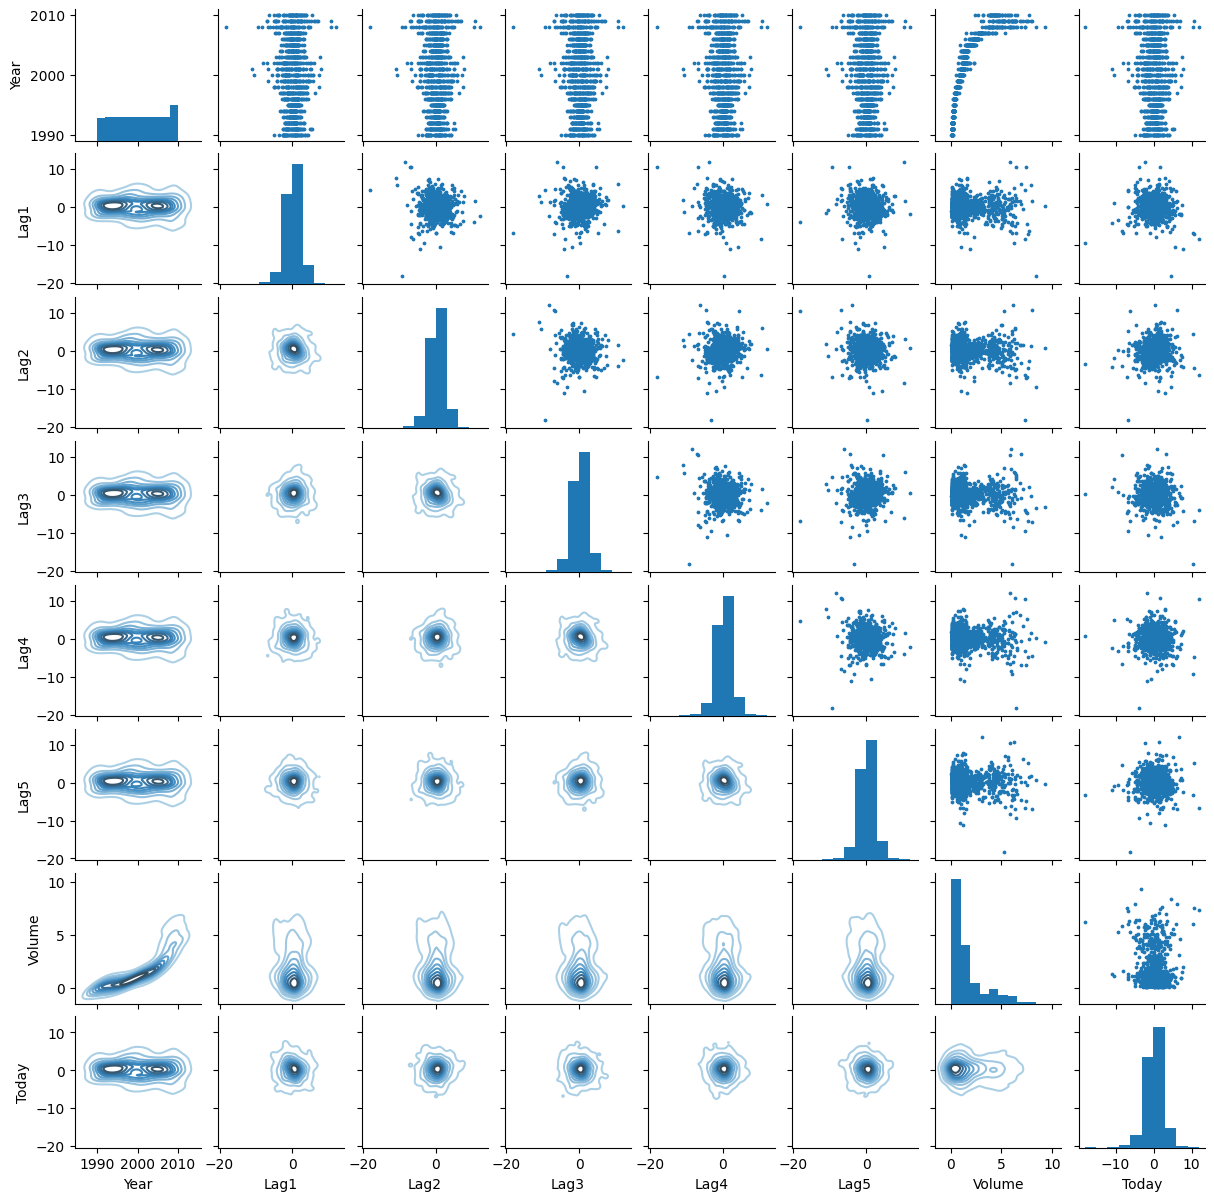

In [12]:
##EDA
g = sns.PairGrid(Weekly)
g.map_upper(plt.scatter, s=3)
g.map_diag(plt.hist)
g.map_lower(sns.kdeplot, cmap="Blues_d")
g.figure.set_size_inches(12, 12)

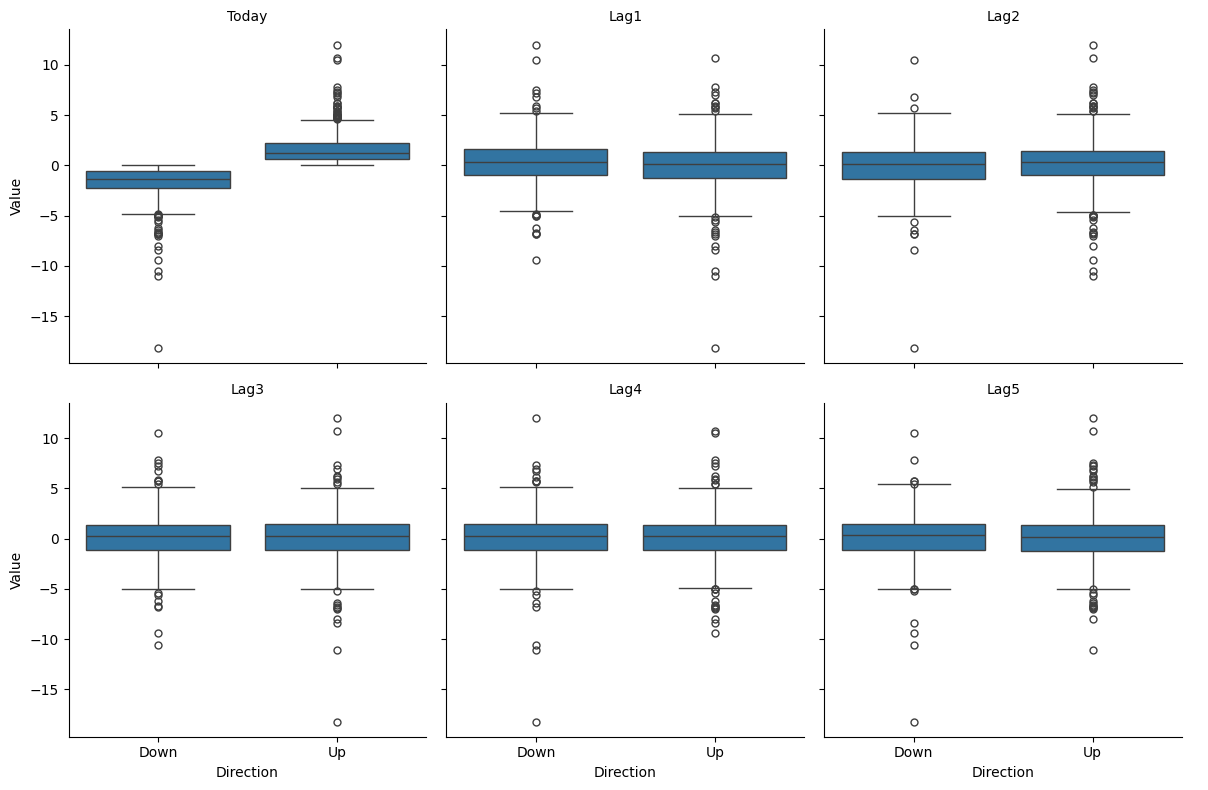

In [13]:
#EDA
# Melt DataFrame to long format
Weekly_melt = Weekly.melt(id_vars=['Direction'],
                  value_vars=['Today', 'Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag5'],
                  var_name='Lag',
                  value_name='Value')

# Create box plots for each Lag variable
g = sns.catplot(x='Direction', y='Value', col='Lag',
                data=Weekly_melt, kind='box',
                col_wrap=3, height=4, aspect=1)
g.set_titles("{col_name}")
plt.show()

In [14]:
#Predictors Statistical Significance
allvars = Weekly.columns.drop(["Today", "Direction", "Year"])
design = MS(allvars)
X = design.fit_transform(Weekly)

y = Weekly["Direction"] == "Up"

glm = sm.GLM(y, X, family=sm.families.Binomial())
results = glm.fit()
summarize(results)

,coef,std err,z,P>|z|
intercept,0.2669,0.086,3.106,0.002
Lag1,-0.0413,0.026,-1.563,0.118
Lag2,0.0584,0.027,2.175,0.030
Lag3,-0.0161,0.027,-0.602,0.547
Lag4,-0.0278,0.026,-1.050,0.294
Lag5,-0.0145,0.026,-0.549,0.583
Volume,-0.0227,0.037,-0.616,0.538


In [15]:
#Confusion Matrix
probs = results.predict(X)

labels = np.array(["Down"] * len(probs))
labels[probs > 0.5] = "Up"

confusion_table(labels, Weekly["Direction"])

Truth,Down,Up
Predicted,,
Down,54,48
Up,430,557


In [16]:
#Confusion Matrix
np.mean(labels == Weekly["Direction"])

(54+ 557)/1089, 605/1089

(0.5610651974288338, 0.5555555555555556)

In [17]:
#Create traing set
train = Weekly[Weekly['Year'] <= 2008]
train.describe()

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today
count,985.000000,985.000000,985.000000,985.000000,985.000000,985.000000,985.000000,985.000000
mean,1999.050761,0.124501,0.127820,0.122884,0.122227,0.120976,1.205973,0.130535
std,5.457286,2.269346,2.269069,2.272617,2.272625,2.274273,1.258204,2.279069
min,1990.000000,-18.195000,-18.195000,-18.195000,-18.195000,-18.195000,0.087465,-18.195000
25%,1994.000000,-1.154000,-1.147000,-1.154000,-1.154000,-1.154000,0.307337,-1.154000
50%,1999.000000,0.231000,0.234000,0.231000,0.230000,0.230000,0.804848,0.231000
75%,2004.000000,1.334000,1.337000,1.337000,1.337000,1.337000,1.515846,1.337000
max,2008.000000,12.026000,12.026000,12.026000,12.026000,12.026000,9.328214,12.026000


In [18]:
#Create test set
test = Weekly[Weekly['Year'] > 2008]
test.describe()

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today
count,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000
mean,2009.500000,0.397635,0.371365,0.377548,0.369250,0.319058,5.066105,0.333298
std,0.502421,3.068538,3.074725,3.075192,3.073895,3.073650,1.147652,3.003296
min,2009.000000,-7.035000,-7.035000,-7.035000,-7.035000,-7.035000,2.390427,-7.035000
25%,2009.000000,-1.060750,-1.214250,-1.214250,-1.214250,-1.323250,4.234228,-1.060750
50%,2009.500000,0.522000,0.461500,0.522000,0.461500,0.437000,4.850717,0.461500
75%,2010.000000,2.239250,2.239250,2.239250,2.239250,2.204250,5.793837,2.204250
max,2010.000000,10.707000,10.707000,10.707000,10.707000,10.707000,7.963276,10.707000


In [19]:
#Lag2 as only predictor
design = MS(['Lag2'])

#Logistic Regression Fit
X = design.fit_transform(train)
y = train['Direction'] == 'Up'

glm = sm.GLM(y,
            X,
            family=sm.families.Binomial())

results = glm.fit()
summarize(results)

,coef,std err,z,P>|z|
intercept,0.2033,0.064,3.162,0.002
Lag2,0.0581,0.029,2.024,0.043


In [20]:
#Predictors Probabilites
X = design.fit_transform(test)
probs = results.predict(X)
probs[:10]



,0
985,0.526129
986,0.644736
987,0.486216
988,0.485200
989,0.519767
990,0.540125
991,0.623348
992,0.480993
993,0.451220
994,0.484881


In [21]:
#Test dataset size
len(test)

104

In [22]:
#Confusion Matrix
labels = np.array(['Down']*104)
labels[probs>0.5] = "Up"
confusion_table(labels, test['Direction'])

Truth,Down,Up
Predicted,,
Down,9,5
Up,34,56


In [23]:
#Predictions accruacy
(9+56)/104, 61/104

(0.625, 0.5865384615384616)

In [24]:
#Linear Discriminant Analysis(LDA)
train = Weekly["Year"] < 2009
test = Weekly["Year"] >= 2009

X_train = Weekly.loc[train, ["Lag2"]]
X_test = Weekly.loc[test, ["Lag2"]]

y_train = Weekly.loc[train, "Direction"]
y_test = Weekly.loc[test, "Direction"]

In [25]:
#LDA fit
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

lda_pred = lda.predict(X_test)

In [26]:
#LDA accruacy
np.mean(lda_pred == y_test)

np.float64(0.625)

In [27]:
#Quadratic Discriminant Analysis (QDA)
qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train, y_train)

qda_pred = qda.predict(X_test)

confusion_table(qda_pred, y_test)

Truth,Down,Up
Predicted,,
Down,0,0
Up,43,61


In [28]:
#QDA accruacy
np.mean(qda_pred == y_test)

np.float64(0.5865384615384616)

In [29]:
#KNN, K=1
knn1 = KNeighborsClassifier(n_neighbors=1)
knn1.fit(X_train, y_train)

knn1_pred = knn1.predict(X_test)

confusion_table(knn1_pred, y_test)

Truth,Down,Up
Predicted,,
Down,22,32
Up,21,29


In [30]:
np.mean(knn1_pred == y_test)

np.float64(0.49038461538461536)

In [31]:
#Using Naive Bayes
nb = GaussianNB()
nb.fit(X_train, y_train)

nb_pred = nb.predict(X_test)

confusion_table(nb_pred, y_test)

Truth,Down,Up
Predicted,,
Down,0,0
Up,43,61


In [32]:
np.mean(nb_pred == y_test)

np.float64(0.5865384615384616)

In [47]:
#Best Method
preds = np.where(probs > 0.5, "Up", "Down")
results_summary = pd.DataFrame({
    "Model": ["Logistic Regression", "LDA", "QDA", "KNN (K=1)", "Naive Bayes"],
    "Accuracy": [
        np.mean(preds == y_test),
        np.mean(lda_pred == y_test),
        np.mean(qda_pred == y_test),
        np.mean(knn1_pred == y_test),
        np.mean(nb_pred == y_test)
    ]
})

results_summary


,Model,Accuracy
0,Logistic Regression,0.625000
1,LDA,0.625000
2,QDA,0.586538
3,KNN (K=1),0.490385
4,Naive Bayes,0.586538


In [48]:
#Additional Methods
#Create the train/test split
train = Weekly["Year"] < 2009
test = Weekly["Year"] >= 2009

y_train = Weekly.loc[train, "Direction"]
y_test = Weekly.loc[test, "Direction"]

In [51]:
#Create transformed and interaction variables
Weekly["Lag1_Lag2"] = Weekly["Lag1"] * Weekly["Lag2"]
Weekly["Lag2_sq"] = Weekly["Lag2"] ** 2
Weekly["Lag1_sq"] = Weekly["Lag1"] ** 2

In [52]:
#Define predictor combinations to test
predictor_sets = {
    "Lag2 only": ["Lag2"],
    "Lag1 + Lag2": ["Lag1", "Lag2"],
    "Lag1 to Lag5": ["Lag1", "Lag2", "Lag3", "Lag4", "Lag5"],
    "Lag2 + Volume": ["Lag2", "Volume"],
    "Lag1 + Lag2 + Interaction": ["Lag1", "Lag2", "Lag1_Lag2"],
    "Lag2 + Lag2 squared": ["Lag2", "Lag2_sq"],
    "Lag1 + Lag2 + Squares": ["Lag1", "Lag2", "Lag1_sq", "Lag2_sq"],
    "All + Interaction": ["Lag1", "Lag2", "Lag3", "Lag4", "Lag5", "Volume", "Lag1_Lag2"]
}

In [53]:
#Import the needed models
import numpy as np
import pandas as pd
import statsmodels.api as sm

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

In [54]:
#Create a function to evaluate each model
def evaluate_model(method, predictors, k=None):
    X_train = Weekly.loc[train, predictors]
    X_test = Weekly.loc[test, predictors]

    if method == "Logistic Regression":
        X_train_sm = sm.add_constant(X_train)
        X_test_sm = sm.add_constant(X_test)

        model = sm.GLM(y_train == "Up", X_train_sm, family=sm.families.Binomial())
        results = model.fit()

        probs = results.predict(X_test_sm)
        preds = np.where(probs > 0.5, "Up", "Down")

    elif method == "LDA":
        model = LinearDiscriminantAnalysis()
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

    elif method == "QDA":
        model = QuadraticDiscriminantAnalysis()
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

    elif method == "Naive Bayes":
        model = GaussianNB()
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

    elif method == "KNN":
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        model = KNeighborsClassifier(n_neighbors=k)
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)

    accuracy = np.mean(preds == y_test)

    confusion = pd.crosstab(
        preds,
        y_test,
        rownames=["Predicted"],
        colnames=["Actual"]
    )

    return accuracy, confusion


In [56]:
#Test logistic regression, LDA, QDA, and Naïve Bayes
results_list = []

methods = ["Logistic Regression", "LDA", "QDA", "Naive Bayes"]

for name, predictors in predictor_sets.items():
    for method in methods:
        accuracy, confusion = evaluate_model(method, predictors)

        results_list.append({
            "Method": method,
            "Predictors": name,
            "Accuracy": accuracy,
            "K": None,
            "Confusion Matrix": confusion
        })

In [57]:
#Test different K values for KNN
k_values = [1, 3, 5, 7, 9, 11, 15, 20]

for name, predictors in predictor_sets.items():
    for k in k_values:
        accuracy, confusion = evaluate_model("KNN", predictors, k=k)

        results_list.append({
            "Method": "KNN",
            "Predictors": name,
            "Accuracy": accuracy,
            "K": k,
            "Confusion Matrix": confusion
        })

In [58]:
#Create a results table
results_df = pd.DataFrame(results_list)

results_df[["Method", "Predictors", "K", "Accuracy"]].sort_values(
    by="Accuracy",
    ascending=False
).head(10)

,Method,Predictors,K,Accuracy
26,QDA,Lag1 + Lag2 + Squares,NaN,0.644231
0,Logistic Regression,Lag2 only,NaN,0.625000
22,QDA,Lag2 + Lag2 squared,NaN,0.625000
1,LDA,Lag2 only,NaN,0.625000
20,Logistic Regression,Lag2 + Lag2 squared,NaN,0.625000
21,LDA,Lag2 + Lag2 squared,NaN,0.615385
60,KNN,Lag2 + Volume,9.0,0.596154
39,KNN,Lag2 only,20.0,0.596154
79,KNN,Lag2 + Lag2 squared,20.0,0.596154
38,KNN,Lag2 only,15.0,0.586538


In [74]:
# 1. Load data
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

train = pd.read_csv("/content/train (1).csv")
test = pd.read_csv("/content/test (2).csv")

target = "NObeyesdad"

# Save test IDs before dropping anything
test_ids = test["id"]

# 2. Separate predictors and target
X = train.drop(columns=[target])
y = train[target]

# 3. Drop id column from both train and test predictors
X = X.drop(columns=["id"])
test_features = test.drop(columns=["id"])

# 4. One-hot encode categorical variables
X_encoded = pd.get_dummies(X, drop_first=True)
test_encoded = pd.get_dummies(test_features, drop_first=True)

# 5. Align train and test columns
X_encoded, test_encoded = X_encoded.align(
    test_encoded,
    join="left",
    axis=1,
    fill_value=0
)

# 6. Train/validation split
X_train, X_val, y_train, y_val = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=1,
    stratify=y
)

# 7. Scale numeric encoded data
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Important: fit final scaler on FULL encoded training data
final_scaler = StandardScaler()
X_full_scaled = final_scaler.fit_transform(X_encoded)
test_scaled = final_scaler.transform(test_encoded)

In [75]:
#train your models
# Logistic Regression
log_model = LogisticRegression(max_iter=10000)
log_model.fit(X_train_scaled, y_train)
log_pred = log_model.predict(X_val_scaled)

# LDA
lda = LinearDiscriminantAnalysis()
lda.fit(X_train_scaled, y_train)
lda_pred = lda.predict(X_val_scaled)

# Naive Bayes
nb = GaussianNB()
nb.fit(X_train_scaled, y_train)
nb_pred = nb.predict(X_val_scaled)

# SVM
svm = SVC(kernel="rbf")
svm.fit(X_train_scaled, y_train)
svm_pred = svm.predict(X_val_scaled)

print("Logistic:", accuracy_score(y_val, log_pred))
print("LDA:", accuracy_score(y_val, lda_pred))
print("Naive Bayes:", accuracy_score(y_val, nb_pred))
print("SVM:", accuracy_score(y_val, svm_pred))

Logistic: 0.8571772639691715
LDA: 0.8143063583815029
Naive Bayes: 0.6139210019267822
SVM: 0.8521194605009634


In [76]:
#Create the Kaggle submission with the best model
best_model = SVC(kernel="rbf")
best_model.fit(X_full_scaled, y)

predictions = best_model.predict(test_scaled)

submission = pd.DataFrame({
    "id": test_ids,
    "NObeyesdad": predictions
})

submission.to_csv("submission.csv", index=False)

submission.head()

,id,NObeyesdad
0,20758,Obesity_Type_II
1,20759,Overweight_Level_I
2,20760,Obesity_Type_III
3,20761,Obesity_Type_I
4,20762,Obesity_Type_III
